# Week 2: Decomposition & Features
## In-Class Exercises

**Objective.** Split a series into trend, seasonality, and remainder; handle more than one seasonal period; and turn a decomposition into a handful of *features* that let you triage hundreds of series at once.

### How this notebook works

Three parts, each building on the one before it.

| Part | Format | Content |
| --- | --- | --- |
| 1 | Walkthrough | STL on the airline series, raw and logged, and what the remainder tells you. |
| 2 | Blanks we fill in together | MSTL on a series with daily, weekly *and* monthly seasonality, plus an outage. |
| 3 | On your own, ~12 min | Trend and seasonal strength across a panel, then rank it. |


In [2]:
!pip install -q pandas numpy plotly matplotlib statsmodels scipy scikit-learn

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.graphics.tsaplots import plot_acf

pio.templates.default = "plotly_white"   # try "plotly_dark", "ggplot2", "simple_white"

# Series overviews are plotly. Decompositions use statsmodels' own res.plot(), and
# correlograms use plot_acf - both matplotlib.

URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
air = pd.read_csv(URL, parse_dates=["Month"], index_col="Month")["Passengers"].asfreq("MS")
air.head()


Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: Passengers, dtype: int64

In [4]:
def show(res, title, size=(9, 7)):
    """statsmodels STL/MSTL results carry their own component plot; just size and title it."""
    fig = res.plot()
    fig.set_size_inches(*size)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


---
## Part 1. STL, and why the transform comes first

STL splits $y_t$ into trend $T_t$, season $S_t$, and remainder $R_t$, additively:

$$y_t = T_t + S_t + R_t$$

*Additively* is doing a lot of work here. The airline series has seasonal swings that grow with the level, which additive STL cannot represent. It tries anyway, and the failure lands in the remainder.

Watch the remainder panel in both fits.

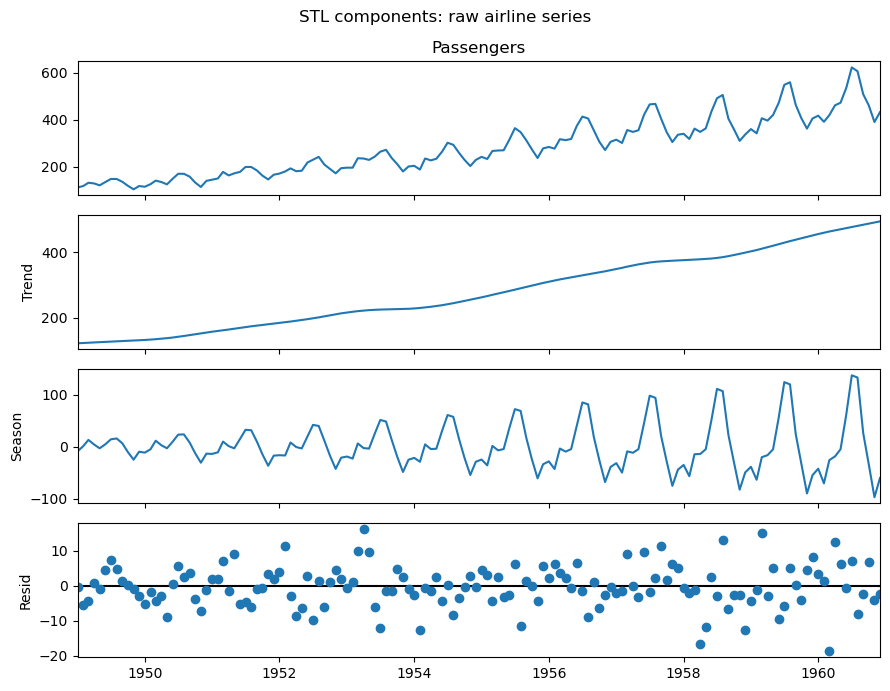

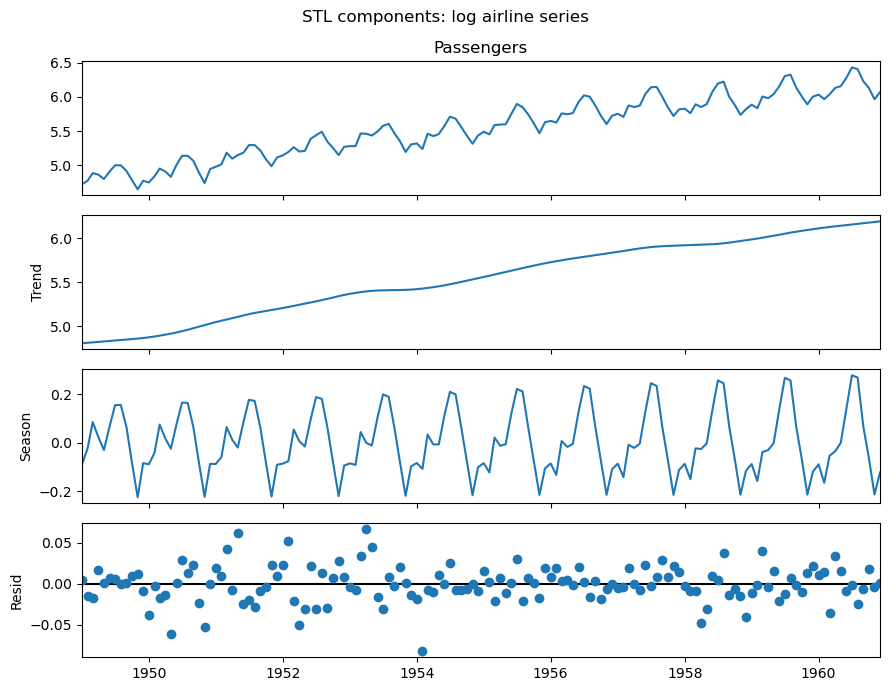

In [5]:
stl_raw = STL(air, seasonal=13).fit()
stl_log = STL(np.log(air), seasonal=13).fit()

show(stl_raw, "STL components: raw airline series")
show(stl_log, "STL components: log airline series")


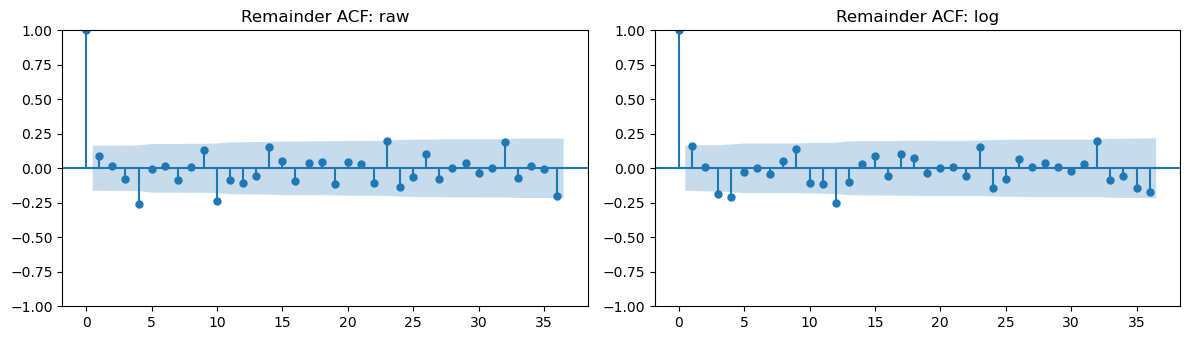

remainder std, raw: 5.963
remainder std, log (as % of level): 2.21


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(stl_raw.resid, lags=36, ax=ax[0], title="Remainder ACF: raw")
plot_acf(stl_log.resid, lags=36, ax=ax[1], title="Remainder ACF: log")
plt.tight_layout()
plt.show()

print("remainder std, raw:", round(stl_raw.resid.std(), 3))
print("remainder std, log (as % of level):", round(100 * stl_log.resid.std(), 3))

**Notice:**

1. The raw remainder fans out, small early and large late. A fixed additive seasonal shape is too small in 1949 and too big in 1960.
2. The raw remainder still has ACF structure at the seasonal lags. Leftover seasonality means the decomposition did not finish its job.
3. On the log scale the seasonal amplitude is constant, additive STL fits, and the remainder looks close to noise.

**Rule of thumb:** if the seasonal swing scales with the level, decompose the log. On the log scale, an additive decomposition *is* a multiplicative one.

---
## Part 2. Several seasonal periods at once

Hourly business data rarely has just one cycle. There is a daily rhythm (period 24) inside a weekly one (period 168), and often a slower billing or payroll cycle on top of that - here about 30 days, period 720. One `seasonal` argument cannot express any of that; MSTL fits the periods in sequence, shortest first.

We build a series with a known answer so the decomposition can be checked against ground truth - and we drop a **six-hour outage** into it, because real data always has one.


In [7]:
rng = np.random.default_rng(7)
n_hours = 24 * 7 * 26          # 26 weeks, so the ~30-day cycle repeats about 6 times
idx = pd.date_range("2024-01-01", periods=n_hours, freq="h")
t = np.arange(n_hours)

true_trend   = 50 + 0.004 * t
true_daily   = 10 * np.sin(2 * np.pi * t / 24 - 1.5)                 # period 24
true_weekly  = -6 * np.isin(idx.dayofweek, [5, 6]).astype(float)     # period 168, weekend dip
true_monthly = 4 * np.sin(2 * np.pi * t / 720)                       # period 720, billing cycle
noise = rng.normal(scale=1.5, size=n_hours)

demand = pd.Series(true_trend + true_daily + true_weekly + true_monthly + noise,
                   index=idx, name="demand")

# One outage, six hours on a Tuesday morning. Not trend, not seasonal - it has to land somewhere.
demand.loc["2024-03-05 08:00":"2024-03-05 13:00"] -= 35

px.line(demand.rename_axis("date").reset_index(), x="date", y="demand",
        title="Simulated hourly demand, 26 weeks (spot the outage in early March)").show()


In [8]:
# TODO - fit MSTL with ALL THREE periods.
#   Hint: MSTL(demand, periods=(24, 168, 720)).fit()

# res.seasonal is a DataFrame with one column per period.
res.seasonal.head()


NameError: name 'res' is not defined

<details>
<summary><b>Show the line</b></summary>

```python
res = MSTL(demand, periods=(24, 168, 720)).fit()
```
</details>


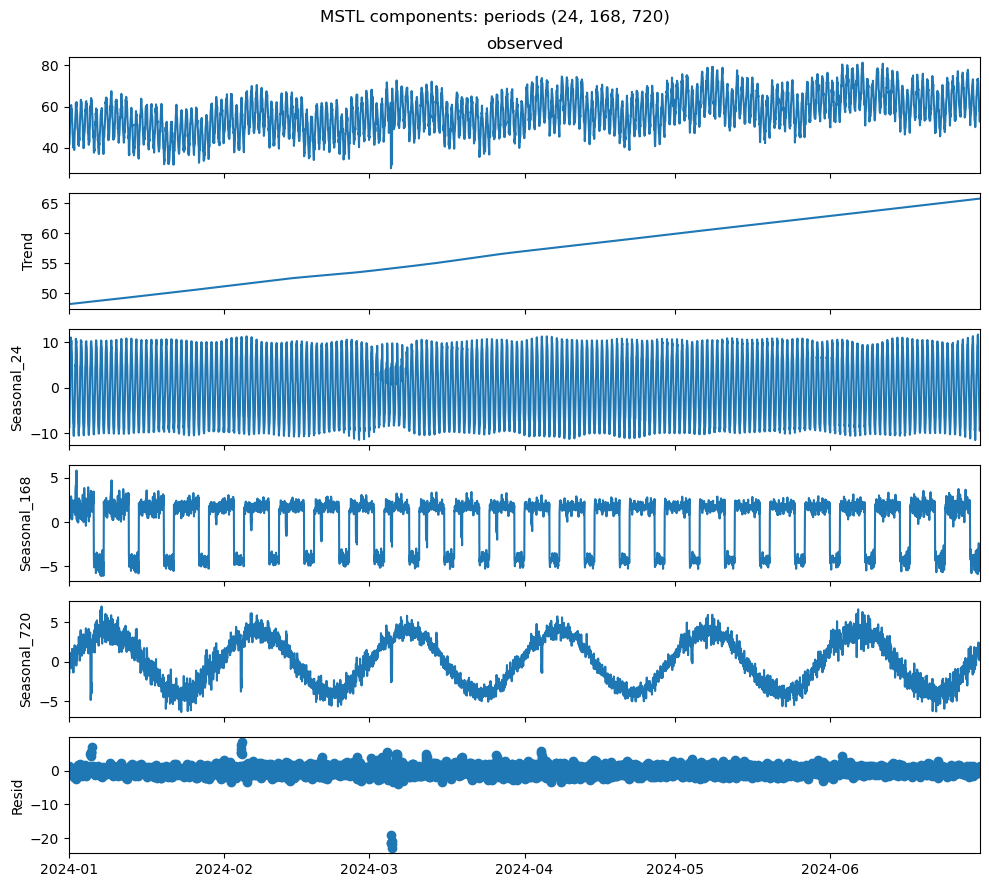

In [ ]:
show(res, "MSTL components: periods (24, 168, 720)", size=(10, 9))

# Three seasonal panels, one per period, plus trend and remainder.
# The outage is the lone spike at the bottom.


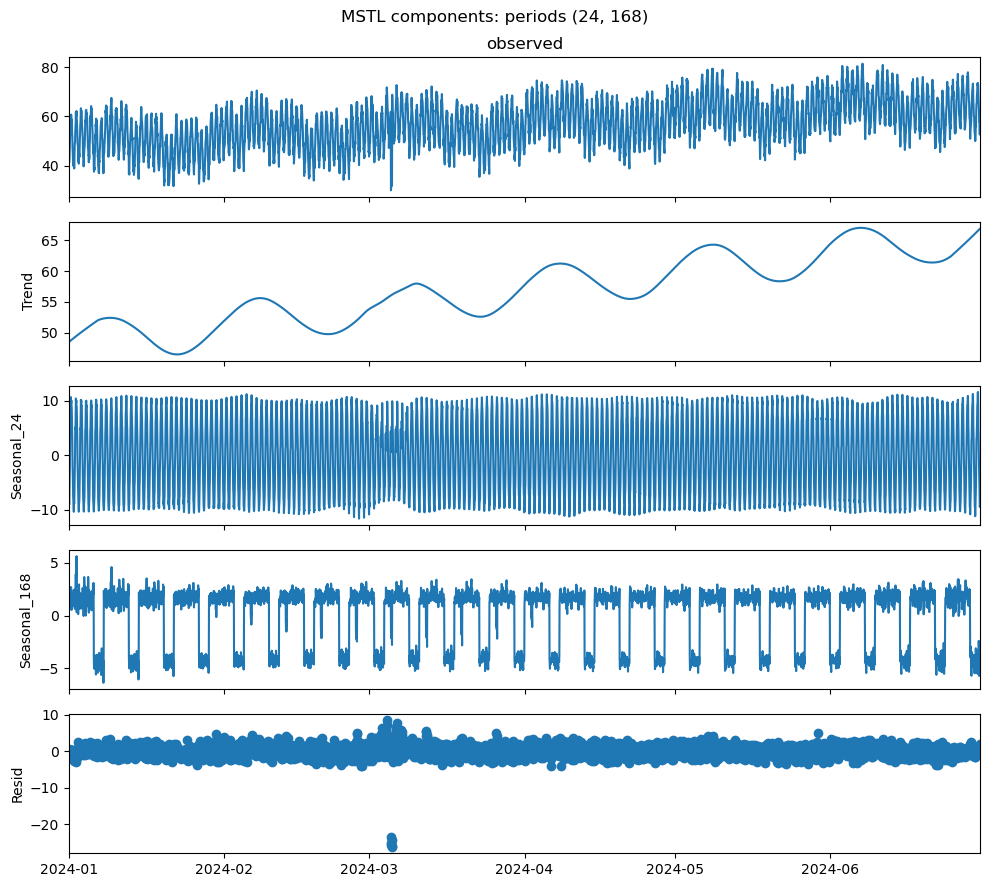

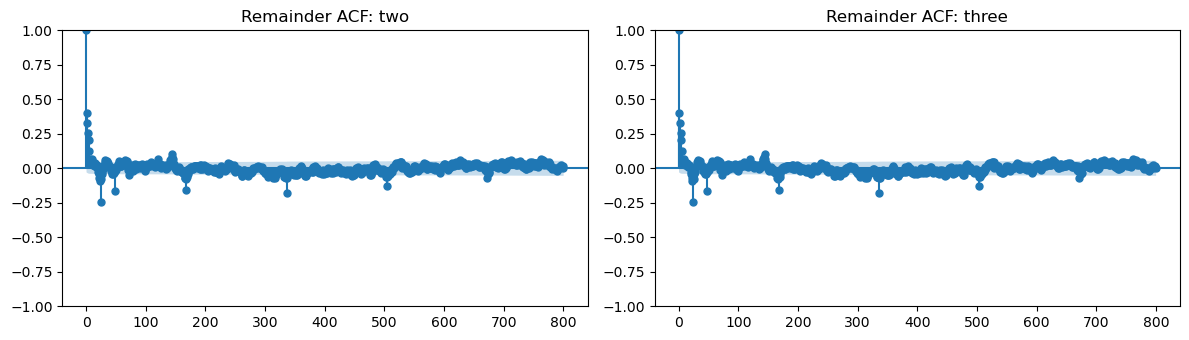

In [ ]:
# Diagnostic: re-fit WITHOUT the ~monthly period and see where that cycle goes.
# TODO - fit MSTL with periods=(24, 168), then compare the two remainders' ACFs out to 800 lags.

# YOUR PLOT HERE

<details>
<summary><b>Solution and what to look for</b></summary>

```python
res_no_monthly = MSTL(demand, periods=(24, 168)).fit()

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
plot_acf(res.resid, lags=800, ax=ax[0], title="Remainder ACF: periods (24, 168, 720)")
plot_acf(res_no_monthly.resid, lags=800, ax=ax[1], title="Remainder ACF: periods (24, 168)")
plt.tight_layout()
plt.show()
```

Dropping a period does not delete the cycle; it relocates it into the remainder, as slow waves that stay positive out past lag 700. Structure in the remainder always means the same thing: *something you did not model is still in the data.*
</details>

### The outage

The six-hour drop is neither trend nor season, so STL has three choices: bend the trend toward it, distort the seasonal shape for those hours-of-day, or leave it in the remainder. The default fit does a little of all three. `robust=True` down-weights outlying points as it iterates, which keeps them out of the trend and seasonal estimates and parks them squarely in the remainder - where you can find them.


In [ ]:
res_robust = MSTL(demand, periods=(24, 168, 720), stl_kwargs={"robust": True}).fit()

window = slice("2024-03-03", "2024-03-08")
cmp = pd.DataFrame({
    "observed":      demand.loc[window],
    "resid_default": res.resid.loc[window],
    "resid_robust":  res_robust.resid.loc[window],
    "daily_default": res.seasonal["seasonal_24"].loc[window],
    "daily_robust":  res_robust.seasonal["seasonal_24"].loc[window],
}).rename_axis("date").reset_index().melt(id_vars="date", var_name="component", value_name="value")

fig = px.line(cmp, x="date", y="value", facet_row="component", height=700,
              title="Outage week: default vs. robust MSTL")
fig.update_yaxes(matches=None)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

print("largest |remainder|, default:", round(res.resid.abs().max(), 2))
print("largest |remainder|, robust :", round(res_robust.resid.abs().max(), 2))

# The cheapest outlier detector you will ever write:
flagged = res_robust.resid[res_robust.resid.abs() > 4 * res_robust.resid.std()]
print("\nflagged hours:")
print(flagged.round(1))


largest |remainder|, default: 26.27
largest |remainder|, robust : 37.07

flagged hours:
2024-01-05 09:00:00    11.2
2024-02-04 09:00:00     8.2
2024-03-05 08:00:00   -32.2
2024-03-05 09:00:00   -29.3
2024-03-05 10:00:00   -31.3
2024-03-05 11:00:00   -37.1
2024-03-05 12:00:00   -34.0
2024-03-05 13:00:00   -35.4
2024-06-03 12:00:00     8.3
2024-06-22 15:00:00     8.4
Name: resid, dtype: float64


The robust fit pushes more of the outage into the remainder and leaves the daily seasonal shape alone. Thresholding the remainder at a few times its own standard deviation is a by-product of the decomposition, not a separate model - and it hands you dates to investigate.


---
## Part 3. Features from a decomposition

About 12 minutes.

With one series you plot it. With a thousand you compute a few numbers per series and sort. The two workhorses come straight out of STL:

$$F_T = \max\!\left(0,\ 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(T_t + R_t)}\right)
\qquad
F_S = \max\!\left(0,\ 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)}\right)$$

Both live in $[0, 1)$. Near 0 means the component explains almost nothing; near 1 means it explains almost everything.

**Tasks.**

1. Finish `features(y, period)` so it returns trend strength, seasonal strength, and the remainder's standard deviation.
2. Run it across the panel of 24 series generated in the next cell.
3. Sort by seasonal strength, then plot the top 2 and bottom 2 and confirm they look the way the numbers say.
4. One series is pure noise and one is pure trend. Identify both from the feature table alone, without plotting.

In [ ]:
def make_panel(n_series=24, n=120, seed=3):
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2015-01-01", periods=n, freq="MS")
    t = np.arange(n)
    out = {}
    for i in range(n_series):
        trend_amp = rng.choice([0.0, 0.05, 0.3, 1.0])
        seas_amp = rng.choice([0.0, 1.0, 5.0, 12.0])
        y = (100 + trend_amp * t
             + seas_amp * np.sin(2 * np.pi * t / 12 + rng.uniform(0, 6))
             + rng.normal(scale=3.0, size=n))
        out[f"s{i:02d}"] = y
    # two ringers, so you know the answer exists
    out["s00"] = 100 + rng.normal(scale=3.0, size=n)              # pure noise
    out["s01"] = 100 + 1.2 * t + rng.normal(scale=3.0, size=n)    # pure trend
    return pd.DataFrame(out, index=idx)

panel = make_panel()

first_four = (panel.iloc[:, :4].rename_axis("date").reset_index()
                   .melt(id_vars="date", var_name="series", value_name="value"))
fig = px.line(first_four, x="date", y="value", facet_row="series", height=600,
              title="First four panel series")
fig.update_yaxes(matches=None)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

NameError: name 'np' is not defined

In [ ]:
def features(y, period=12):
    """Return {'trend_strength', 'seasonal_strength', 'resid_sd'} for one series."""
    res = STL(pd.Series(y), period=period, seasonal=13).fit()
    var_r = np.var(res.resid)
    # TODO - fill in the two strength calculations using the formulas above
    trend_strength = ...
    seasonal_strength = ...
    return {"trend_strength": trend_strength,
            "seasonal_strength": seasonal_strength,
            "resid_sd": np.std(res.resid)}


# feat = pd.DataFrame({c: features(panel[c]) for c in panel}).T
# feat.round(3).sort_values("seasonal_strength", ascending=False)

In [ ]:
# YOUR CODE HERE - tasks 2, 3 and 4

: 

<details>
<summary><b>Solution</b></summary>

```python
def features(y, period=12):
    res = STL(pd.Series(y), period=period, seasonal=13).fit()
    var_r = np.var(res.resid)
    trend_strength = max(0.0, 1 - var_r / np.var(res.trend + res.resid))
    seasonal_strength = max(0.0, 1 - var_r / np.var(res.seasonal + res.resid))
    return {"trend_strength": trend_strength,
            "seasonal_strength": seasonal_strength,
            "resid_sd": np.std(res.resid)}

feat = pd.DataFrame({c: features(panel[c].to_numpy()) for c in panel}).T
ranked = feat.sort_values("seasonal_strength", ascending=False)
print(ranked.round(3))

extremes = list(ranked.index[:2]) + list(ranked.index[-2:])
tidy = (panel[extremes].rename_axis("date").reset_index()
             .melt(id_vars="date", var_name="series", value_name="value"))
fig = px.line(tidy, x="date", y="value", facet_row="series", height=700,
              title="Top 2 and bottom 2 by seasonal strength")
fig.update_yaxes(matches=None)
fig.show()

# Task 4: pure noise = both strengths near 0; pure trend = high trend, low seasonal.
print("\npure noise candidate :", feat.eval("trend_strength + seasonal_strength").idxmin())
print("pure trend candidate:", feat.query("seasonal_strength < 0.2").trend_strength.idxmax())
```

**The point.** Two numbers per series turn an unreadable panel into a ranked list. This is how you decide which series get a hand-tuned model and which get seasonal naive, and how M4-style entries route series to model families.
</details>

---
## Wrap-up

1. **Transform, then decompose.** Additive machinery on multiplicative data pushes error into the remainder.
2. **Structure in the remainder is a to-do list.** A bump out at lag 720 means you forgot the monthly cycle.
3. **Outliers are a remainder story too.** Fit robustly, then read the remainder for the dates worth investigating.
4. **Features turn a panel into a ranked list.** Two numbers per series decide where your modeling time goes.

Next week: ETS and ARIMA.
